In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches

# Plots for the Congress
* Study case in March 2024

## Load Data

In [2]:
# Particle paths 
hist_5 = xr.open_dataset("_hist_AT_N_congress.nc").compute().histogram_lon_lat
# print(hist_5)

In [3]:
## SSH 
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/ssh_cs.nc')
ssh

<xarray.Dataset> Size: 352MB
Dimensions:    (time: 61, latitude: 1201, longitude: 1201)
Coordinates:
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 488B 2024-03-01 2024-03-02 ... 2024-04-30
Data variables:
    zos        (time, latitude, longitude) float32 352MB ...
Attributes:
    source:                    MOI GLO12
    Conventions:               CF-1.8
    title:                     daily mean fields from Global Ocean Physics An...
    references:                http://marine.copernicus.eu
    institution:               Mercator Ocean International
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    credit:                    E.U. Copernicus Marine Service Information (CM...
    contact:                   https://marine.copernicus.eu/contact
    copernicusmarine_version:  2.2.0

In [4]:
## Salinity
sal = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/sal_cs.nc')
sal = sal.compute()
# sal5

In [5]:
## UV
UV = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/uv_cs.nc')
UV = UV.compute()
# UV5

In [6]:
## optics
optics = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/optics_cs.nc')
optics = optics.compute()
optics

<xarray.Dataset> Size: 450MB
Dimensions:    (time: 61, latitude: 960, longitude: 960)
Coordinates:
  * latitude   (latitude) float32 4kB -9.979 -9.938 -9.896 ... 29.9 29.94 29.98
  * longitude  (longitude) float32 4kB -74.98 -74.94 -74.9 ... -35.06 -35.02
  * time       (time) datetime64[ns] 488B 2024-03-01 2024-03-02 ... 2024-04-30
Data variables:
    KD490      (time, latitude, longitude) float32 225MB nan nan ... 0.02733
    ZSD        (time, latitude, longitude) float32 225MB nan nan ... 39.63 39.57
Attributes:
    title:        cmems_obs-oc_glo_bgc-transp_my_l4-gapfree-multi-4km_P1D
    history:      Created using software developed at ACRI-ST
    institution:  ACRI
    Conventions:  CF-1.8, ACDD-1.3
    comment:      average
    references:   http://www.globcolour.info GlobColour has been originally f...
    contact:      servicedesk.cmems@acri-st.fr
    source:       surface observation

## Extract selected dates

In [7]:
hist_cs = hist_5.sel(start_time=slice('2024-03-06','2024-04-01'))

* create an algorithm that calculates the tracer values 5 days and 10 days after the release or start_time

In [8]:
from datetime import datetime, timedelta

def find_next_X_days(days,iteration):
    t = datetime.strptime(str(hist_cs.start_time.values[iteration])[:10],"%Y-%m-%d")
    tx = str(t + timedelta(days=days))[:10]

    print('initial time', t)
    print(f'{days} days more', tx)
    return t,tx


In [9]:
for i in range(4):
    t,tx = find_next_X_days(10,i)

initial time 2024-03-06 00:00:00
10 days more 2024-03-16
initial time 2024-03-11 00:00:00
10 days more 2024-03-21
initial time 2024-03-16 00:00:00
10 days more 2024-03-26
initial time 2024-03-21 00:00:00
10 days more 2024-03-31


In [10]:
# sal = sal.drop_vars('depth')
sal.sel(time=slice(t,tx)).mean(dim='time')

<xarray.Dataset> Size: 6MB
Dimensions:    (latitude: 1201, longitude: 1201)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
Data variables:
    so         (latitude, longitude) float32 6MB 34.17 34.17 ... 35.33 35.31

initial time 2024-03-06 00:00:00
10 days more 2024-03-16
initial time 2024-03-11 00:00:00
10 days more 2024-03-21
initial time 2024-03-16 00:00:00
10 days more 2024-03-26
initial time 2024-03-21 00:00:00
10 days more 2024-03-31
initial time 2024-03-26 00:00:00
10 days more 2024-04-05
initial time 2024-03-31 00:00:00
10 days more 2024-04-10


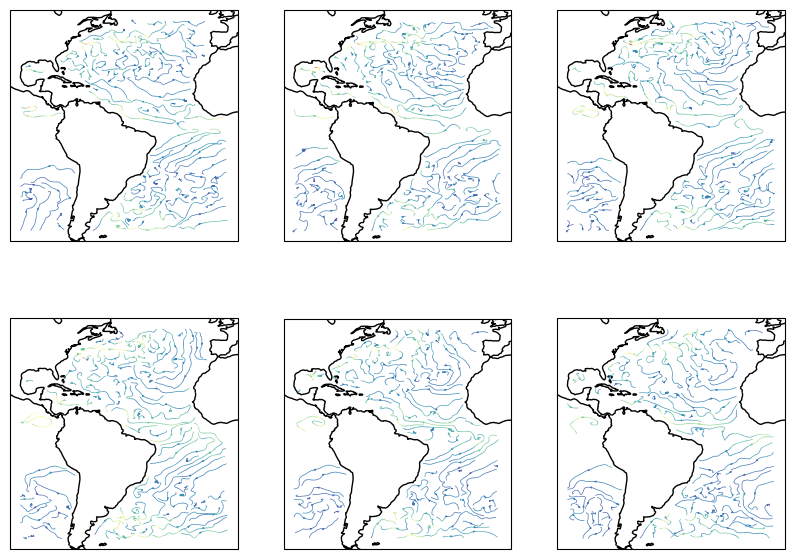

In [11]:
# 0) Precompute means once (lazy if dask-backed)
windows = [find_next_X_days(10, i) for i in range(6)]
U_mean = [UV.U.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
V_mean = [UV.V.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
UV_mean = [UV.speed.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]

# 1) Decimate spatially before computing .values
s = 6  # stride; increase for more speed
x = UV.longitude.isel(longitude=slice(None, None, s)).values
y = UV.latitude.isel(latitude=slice(None, None, s)).values

fig, ax = plt.subplots(2, 3, figsize=(10, 20), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

for i in range(6):
    u = U_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
    v = V_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
    uv = UV_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values

    # MUCH faster than streamplot:
    ax[i].streamplot(x, y, u, v, color=uv, transform=ccrs.PlateCarree(),
                 density=5, arrowsize=0.25, linewidth=0.5,cmap='Spectral_r')
    ax[i].coastlines()

fig.subplots_adjust(wspace=0.2, hspace=-0.75)

initial time 2024-03-06 00:00:00
10 days more 2024-03-16
initial time 2024-03-11 00:00:00
10 days more 2024-03-21
initial time 2024-03-16 00:00:00
10 days more 2024-03-26
initial time 2024-03-21 00:00:00
10 days more 2024-03-31
initial time 2024-03-26 00:00:00
10 days more 2024-04-05
initial time 2024-03-31 00:00:00
10 days more 2024-04-10


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


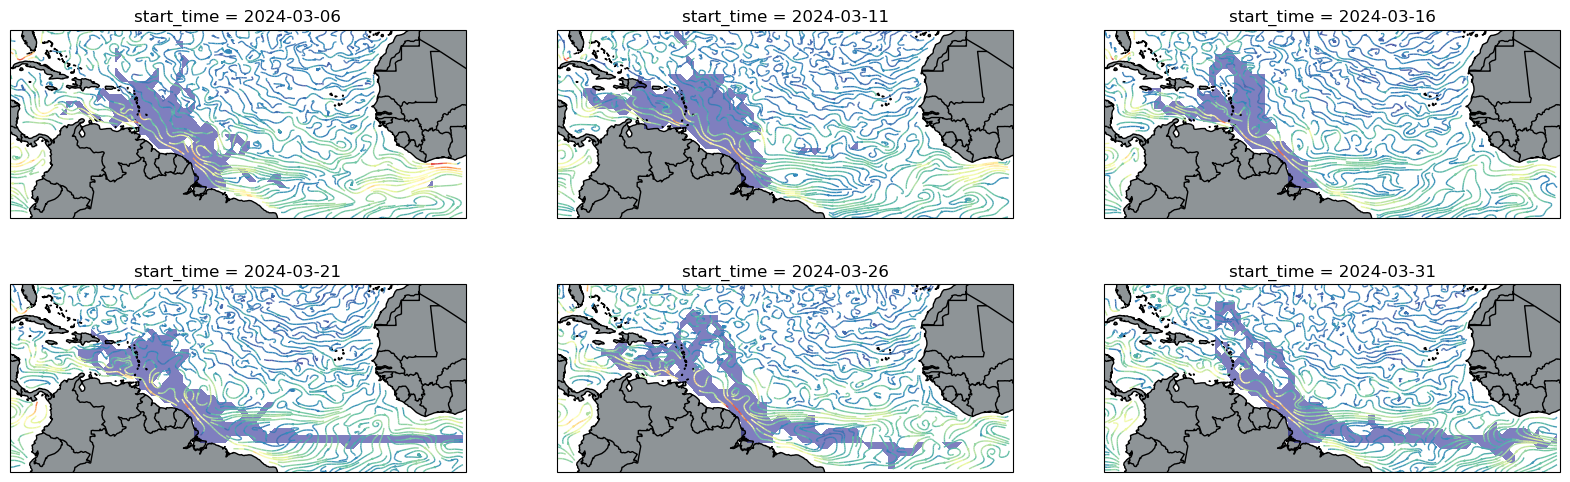

In [12]:
# 0) Precompute means once (lazy if dask-backed)
days =10
windows = [find_next_X_days(days, i) for i in range(6)]
U_mean = [UV.U.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
V_mean = [UV.V.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
UV_mean = [UV.speed.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]

# 1) Decimate spatially before computing .values
s = 3  # stride; increase for more speed
x = UV.longitude.isel(longitude=slice(None, None, s)).values
y = UV.latitude.isel(latitude=slice(None, None, s)).values

fig, ax = plt.subplots(2, 3, figsize=(10*2,20*2), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

for i in range(0,6): 

    
    dat = hist_cs.isel(start_time=i).sum("obs")    
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[i],
                    add_colorbar=False,colors='#000080',alpha = 0.5, levels=[0,hist_5.max()]
                )
    u = U_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
    v = V_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
    uv = UV_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values

    # streamplot
    ax[i].streamplot(x, y, u, v, color=uv, transform=ccrs.PlateCarree(),
                 density=3, arrowsize=0.2, linewidth=1, cmap='Spectral_r')

    ax[i].coastlines()
    ax[i].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[i].add_feature(cf.BORDERS)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)

fig.subplots_adjust(wspace=0.2, hspace=-0.91)

# plt.savefig(f'Stream_plot_cs_{days}_days_colors.png',dpi=300, bbox_inches='tight')


initial time 2024-03-06 00:00:00
5 days more 2024-03-11
initial time 2024-03-11 00:00:00
5 days more 2024-03-16
initial time 2024-03-16 00:00:00
5 days more 2024-03-21
initial time 2024-03-21 00:00:00
5 days more 2024-03-26
initial time 2024-03-26 00:00:00
5 days more 2024-03-31
initial time 2024-03-31 00:00:00
5 days more 2024-04-05


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


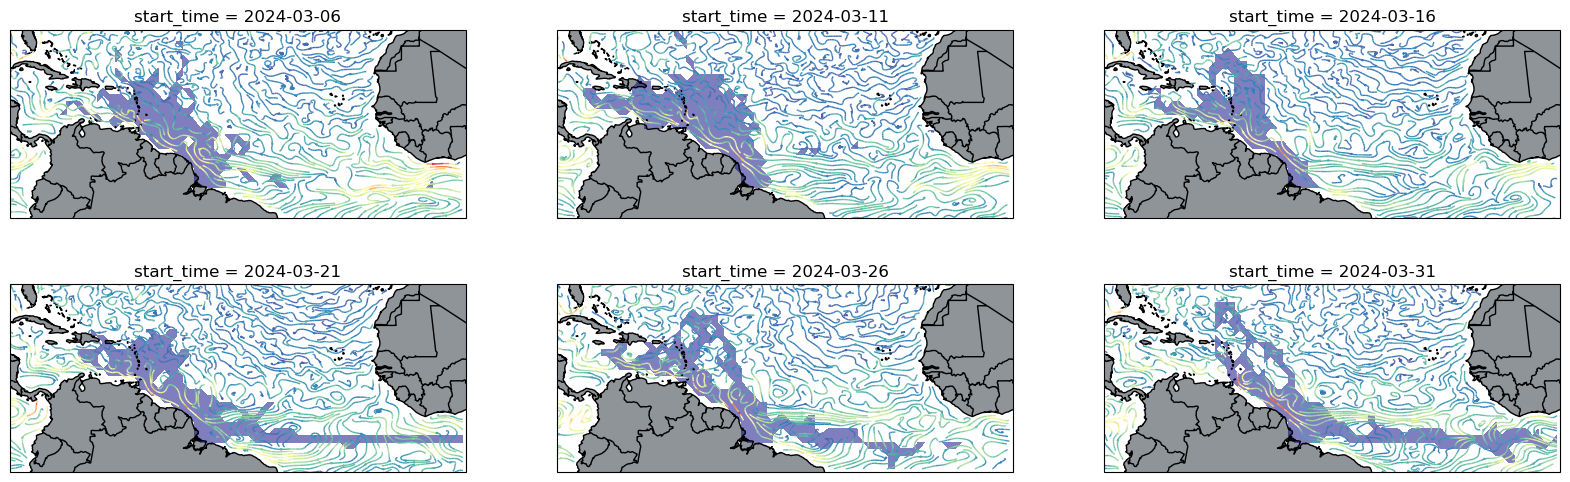

In [13]:
days = 5
windows = [find_next_X_days(days, i) for i in range(6)]
U_mean = [UV.U.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
V_mean = [UV.V.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
UV_mean = [UV.speed.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]

# 1) Decimate spatially before computing .values
s = 3  # stride; increase for more speed
x = UV.longitude.isel(longitude=slice(None, None, s)).values
y = UV.latitude.isel(latitude=slice(None, None, s)).values

fig, ax = plt.subplots(2, 3, figsize=(10*2,20*2), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

for i in range(0,6): 
    
    dat = hist_cs.isel(start_time=i).sum("obs")    
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[i],
                    add_colorbar=False,colors='#000080',alpha = 0.5, levels=[0,hist_5.max()]
                )
    u = U_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
    v = V_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
    uv = UV_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values

    # streamplot
    ax[i].streamplot(x, y, u, v, color=uv, transform=ccrs.PlateCarree(),
                 density=3, arrowsize=0.2, linewidth=1, cmap='Spectral_r')

    ax[i].coastlines()
    ax[i].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[i].add_feature(cf.BORDERS)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)

fig.subplots_adjust(wspace=0.2, hspace=-0.91)

# plt.savefig(f'Stream_plot_cs_{days}_days_colors.png',dpi=300, bbox_inches='tight')

### Tracers plotter

In [14]:
def plotting_tracers(days,tracer,cmap,lines_color,lines_density=None,lw=None):
        #lines_density default = 3
        #provide a tracer that is a data array
    if lines_density is None:
        lines_density=3

    if lw  is None:
        lw = 0.5
        
    days = days
    
    windows = [find_next_X_days(days, i) for i in range(6)]
    U_mean = [UV.U.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
    V_mean = [UV.V.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
    tracer_mean = [tracer.sel(time=slice(t0,t1)).mean(dim='time') for t0, t1 in windows]
    
    # 1) Decimate spatially before computing .values
    s = 3  # stride; increase for more speed
    x = UV.longitude.isel(longitude=slice(None, None, s)).values
    y = UV.latitude.isel(latitude=slice(None, None, s)).values
    lon = tracer.longitude.values
    lat = tracer.latitude.values
    
    fig, ax = plt.subplots(2, 3, figsize=(10*2,20*2), subplot_kw=dict(projection=ccrs.PlateCarree()))
    ax = ax.ravel()
    
    for i in range(0,6): 
    
        u = U_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
        v = V_mean[i].isel(longitude=slice(None, None, s), latitude=slice(None, None, s)).values
        ss = tracer_mean[i].values
        
        #robust 
        p2, p98 = np.nanpercentile(ss, [2, 98])
        
        ax[i].pcolormesh(lon, lat, ss,
                   vmin=p2, vmax=p98, cmap=cmap, shading='auto')
        
        # streamplot
        ax[i].streamplot(x, y, u, v, color=lines_color, transform=ccrs.PlateCarree(),
                     density=lines_density, arrowsize=0.2, linewidth=lw)
    
        ax[i].coastlines()
        ax[i].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
        ax[i].add_feature(cf.BORDERS)
        ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
        t = str(windows[i][0])[:10]
        
        ax[i].set_title(f'start_time = {t}')
        
    fig.subplots_adjust(wspace=0.2, hspace=-0.91)
    # plt.savefig(f'{tracer}_cs_{days}_days_colors.png',dpi=300, bbox_inches='tight')


## Salinity

initial time 2024-03-06 00:00:00
10 days more 2024-03-16
initial time 2024-03-11 00:00:00
10 days more 2024-03-21
initial time 2024-03-16 00:00:00
10 days more 2024-03-26
initial time 2024-03-21 00:00:00
10 days more 2024-03-31
initial time 2024-03-26 00:00:00
10 days more 2024-04-05
initial time 2024-03-31 00:00:00
10 days more 2024-04-10


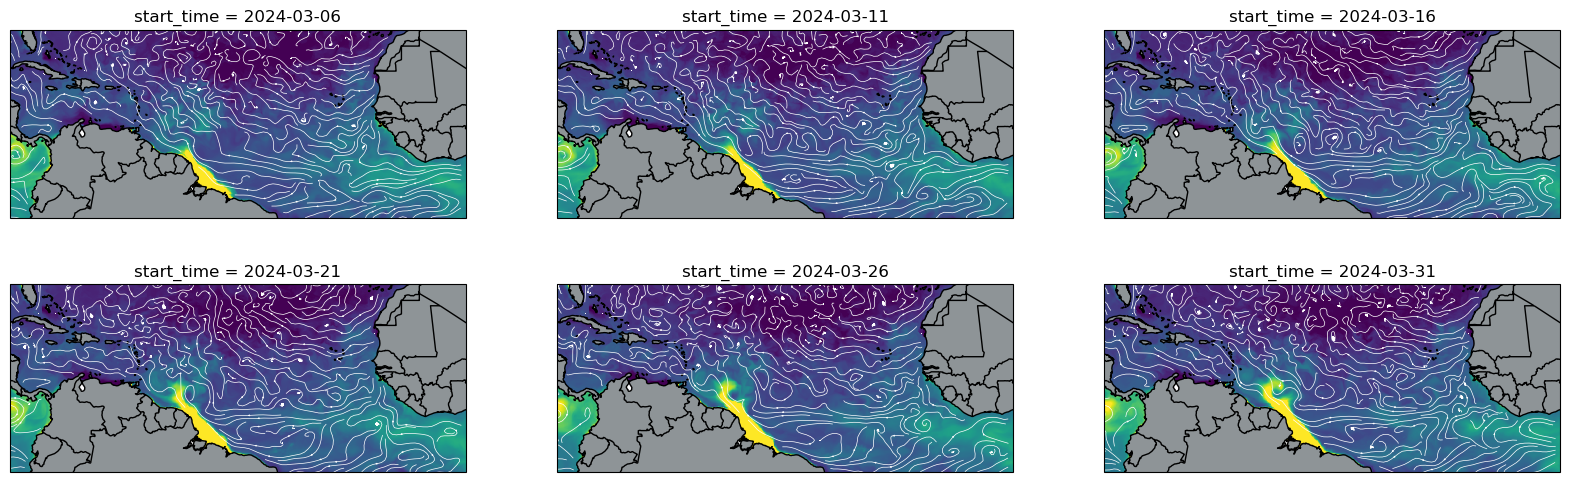

In [15]:
plotting_tracers(days=10,tracer=sal.so,cmap='viridis_r',lines_color='w',lines_density=4)
# plt.savefig(f'Salinity_cs_10_days_colors.png',dpi=300, bbox_inches='tight')

initial time 2024-03-06 00:00:00
5 days more 2024-03-11
initial time 2024-03-11 00:00:00
5 days more 2024-03-16
initial time 2024-03-16 00:00:00
5 days more 2024-03-21
initial time 2024-03-21 00:00:00
5 days more 2024-03-26
initial time 2024-03-26 00:00:00
5 days more 2024-03-31
initial time 2024-03-31 00:00:00
5 days more 2024-04-05


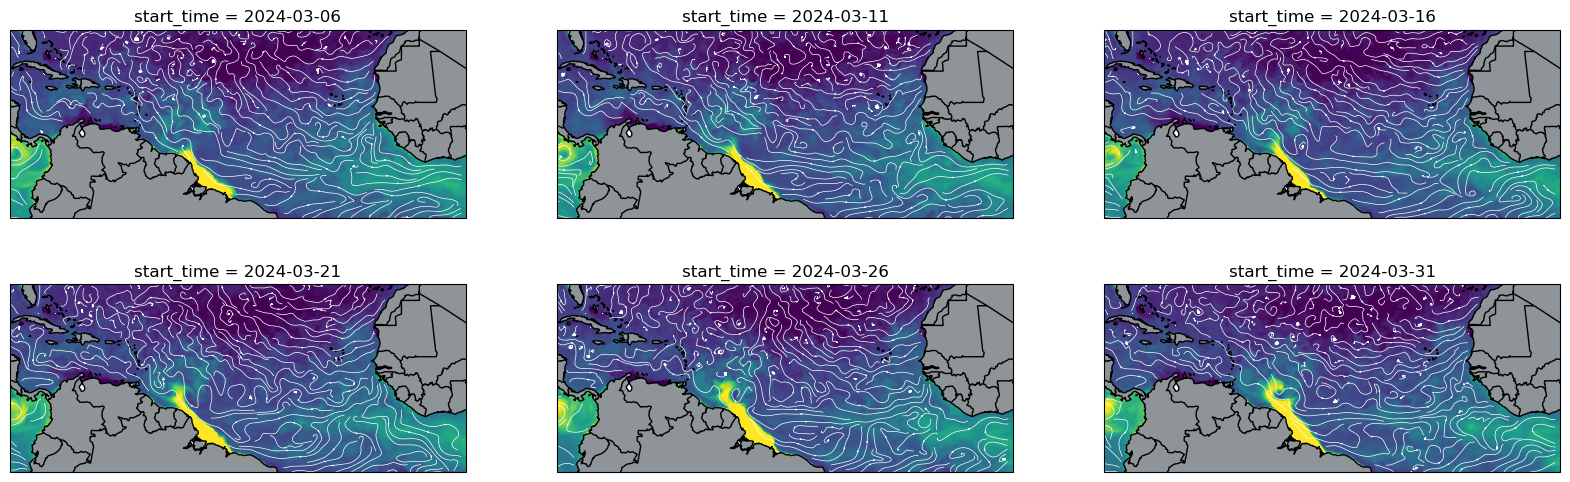

In [16]:
plotting_tracers(days=5,tracer=sal.so,cmap='viridis_r',lines_color='w',lines_density=4)
# plt.savefig(f'Salinity_cs_5_days_colors.png',dpi=300, bbox_inches='tight')

## UV

initial time 2024-03-06 00:00:00
5 days more 2024-03-11
initial time 2024-03-11 00:00:00
5 days more 2024-03-16
initial time 2024-03-16 00:00:00
5 days more 2024-03-21
initial time 2024-03-21 00:00:00
5 days more 2024-03-26
initial time 2024-03-26 00:00:00
5 days more 2024-03-31
initial time 2024-03-31 00:00:00
5 days more 2024-04-05


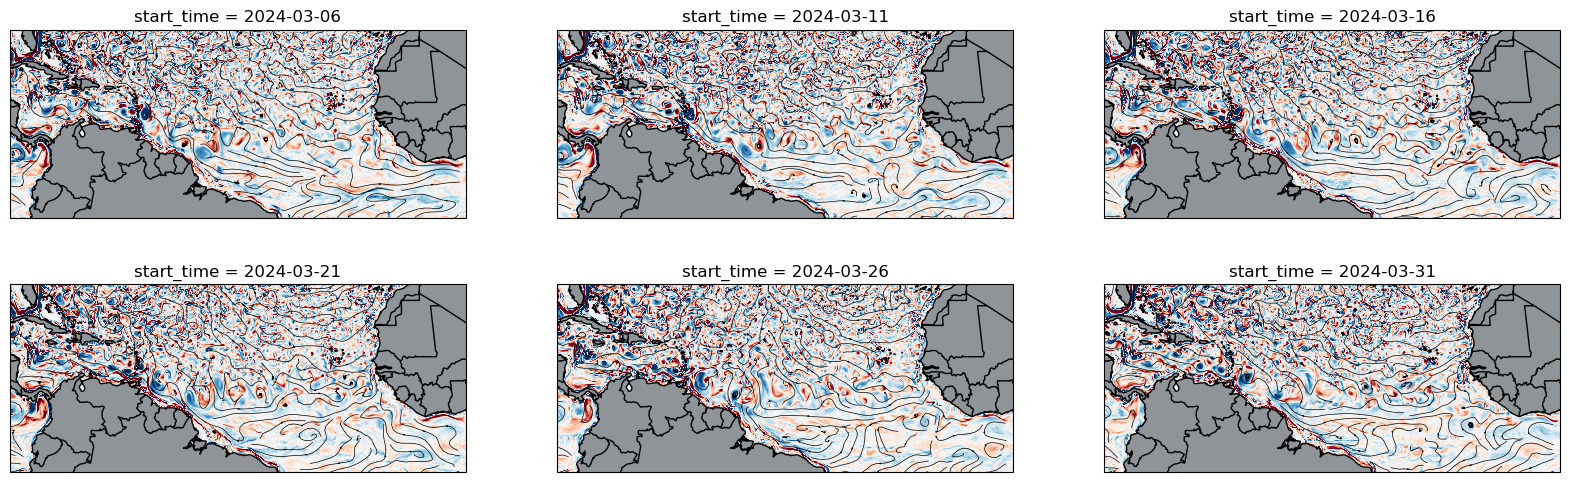

In [17]:
plotting_tracers(days=5,tracer=UV.vorticity,cmap='RdBu_r',lines_color='k')
# plt.savefig(f'Vorticity_cs_5_days_colors.png',dpi=300, bbox_inches='tight')

initial time 2024-03-06 00:00:00
10 days more 2024-03-16
initial time 2024-03-11 00:00:00
10 days more 2024-03-21
initial time 2024-03-16 00:00:00
10 days more 2024-03-26
initial time 2024-03-21 00:00:00
10 days more 2024-03-31
initial time 2024-03-26 00:00:00
10 days more 2024-04-05
initial time 2024-03-31 00:00:00
10 days more 2024-04-10


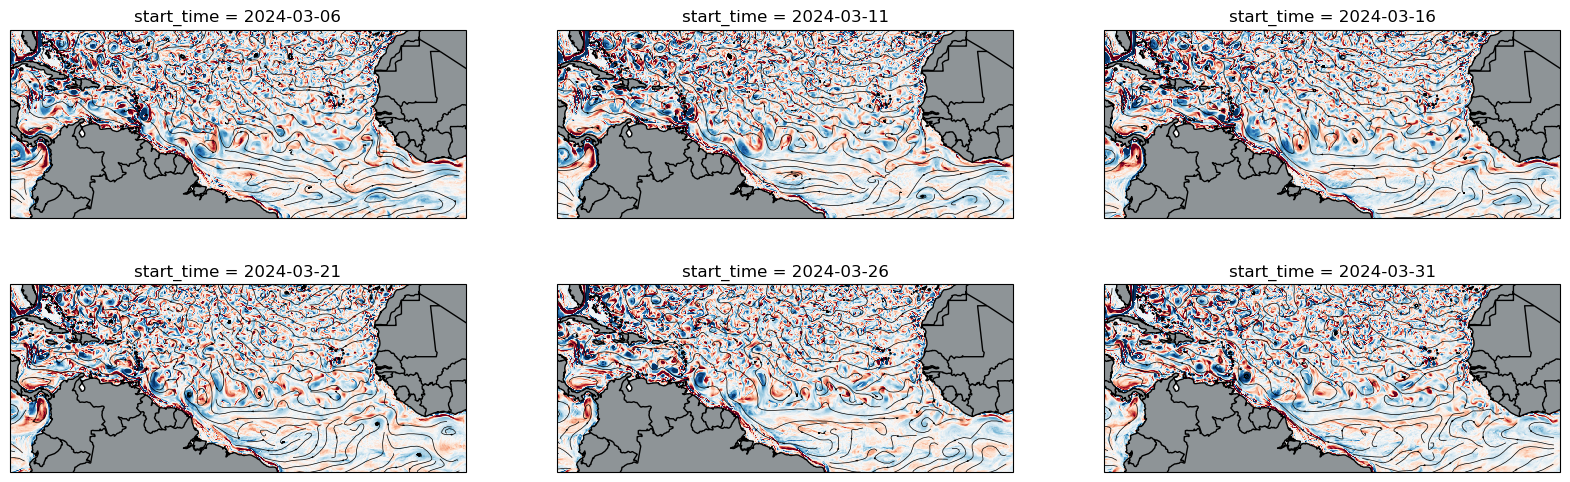

In [21]:
plotting_tracers(days=10,tracer=UV.vorticity,cmap='RdBu_r',lines_color='k')
plt.savefig(f'Vorticity_cs_10_days_colors.png',dpi=300, bbox_inches='tight')

## KD90 

In [18]:
optics

<xarray.Dataset> Size: 450MB
Dimensions:    (time: 61, latitude: 960, longitude: 960)
Coordinates:
  * latitude   (latitude) float32 4kB -9.979 -9.938 -9.896 ... 29.9 29.94 29.98
  * longitude  (longitude) float32 4kB -74.98 -74.94 -74.9 ... -35.06 -35.02
  * time       (time) datetime64[ns] 488B 2024-03-01 2024-03-02 ... 2024-04-30
Data variables:
    KD490      (time, latitude, longitude) float32 225MB nan nan ... 0.02733
    ZSD        (time, latitude, longitude) float32 225MB nan nan ... 39.63 39.57
Attributes:
    title:        cmems_obs-oc_glo_bgc-transp_my_l4-gapfree-multi-4km_P1D
    history:      Created using software developed at ACRI-ST
    institution:  ACRI
    Conventions:  CF-1.8, ACDD-1.3
    comment:      average
    references:   http://www.globcolour.info GlobColour has been originally f...
    contact:      servicedesk.cmems@acri-st.fr
    source:       surface observation

initial time 2024-03-06 00:00:00
5 days more 2024-03-11
initial time 2024-03-11 00:00:00
5 days more 2024-03-16
initial time 2024-03-16 00:00:00
5 days more 2024-03-21
initial time 2024-03-21 00:00:00
5 days more 2024-03-26
initial time 2024-03-26 00:00:00
5 days more 2024-03-31
initial time 2024-03-31 00:00:00
5 days more 2024-04-05


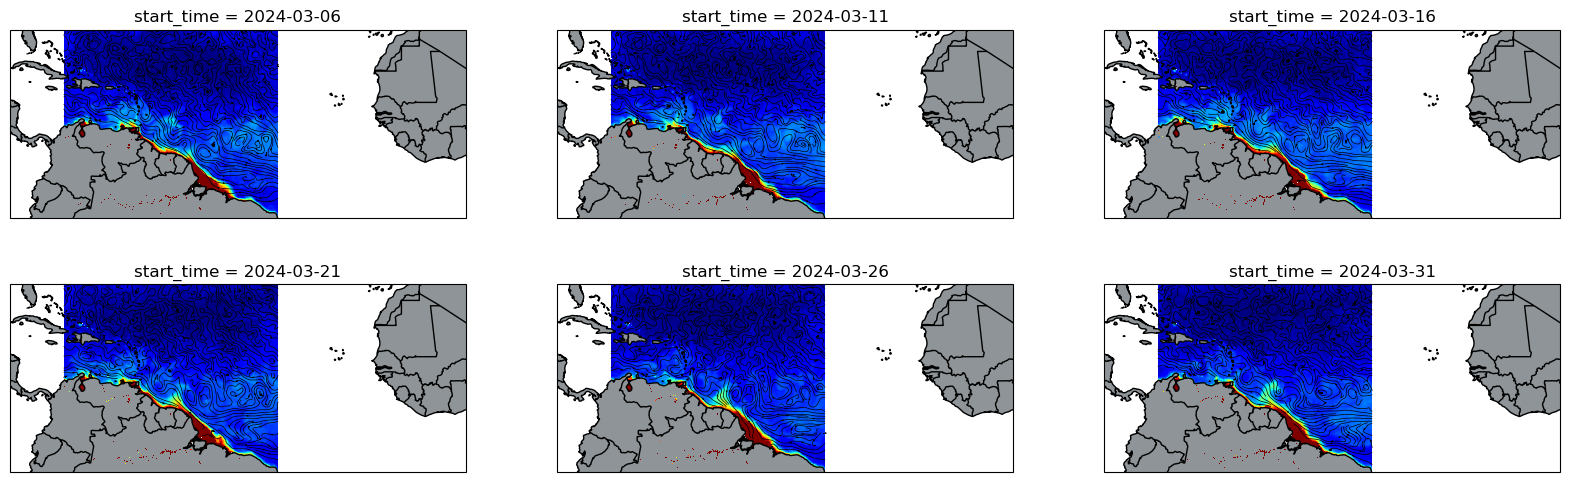

In [24]:
plotting_tracers(days=5,tracer=np.log10(optics.KD490),cmap='jet',lines_color='k')

initial time 2024-03-06 00:00:00
5 days more 2024-03-11
initial time 2024-03-11 00:00:00
5 days more 2024-03-16
initial time 2024-03-16 00:00:00
5 days more 2024-03-21
initial time 2024-03-21 00:00:00
5 days more 2024-03-26
initial time 2024-03-26 00:00:00
5 days more 2024-03-31
initial time 2024-03-31 00:00:00
5 days more 2024-04-05


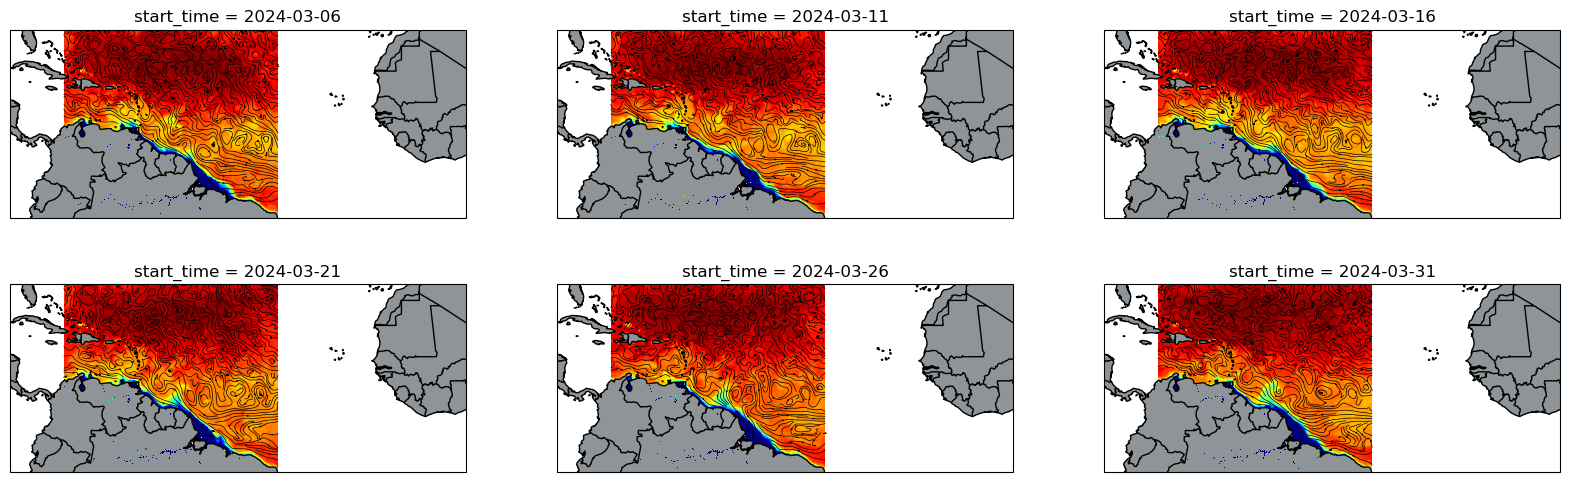

In [25]:
plotting_tracers(days=5,tracer=np.log(optics.ZSD),cmap='jet',lines_color='k')

* Try KD490 anomalies
* Salinity anonmalies
* SZD anomalies 